# Step 8 — Environmental Justice Overlay

**Objective:** Test whether climate-amplified outage risk disproportionately affects disadvantaged communities.

**Data source:** EPA EJScreen 2024 — https://www.epa.gov/ejscreen or https://zenodo.org/records/14767363

**Tests:**
1. Outage rates by EJ burden quartile
2. Regression: outage severity controlling for weather in high-EJ counties
3. Interaction: compound weather x EJ burden
4. Forward projection: high-EJ + high-heat counties by 2050

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from config.settings import PROCESSED, ERCOT_FIPS
from src.data.ejscreen import build_ercot_ejscreen
from src.analysis.panel_regression import run_panel_ols, summarise_results


## 8.1 Build county-level EJ indicators

In [2]:
try:
    ej_ercot = build_ercot_ejscreen()
    print(f'ERCOT EJScreen counties: {len(ej_ercot)}')
    print(ej_ercot.head())
except FileNotFoundError as e:
    print(f'EJScreen not found:\n{e}')
    ej_ercot = None


ERCOT EJScreen counties: 254
       total_pop  ej_index  pct_minority  pct_lowinc  ling_iso_pct  \
fips                                                                 
48001    58077.0  1.759157      0.432908    0.457610      0.011943   
48003    18362.0  1.687020      0.615674    0.303086      0.088559   
48005    86608.0  1.613413      0.407076    0.412904      0.023907   
48007    24048.0  1.429206      0.341317    0.378816      0.024227   
48009     8649.0  0.849871      0.128339    0.275785      0.021055   

       less_hs_pct  pm25_pctile  ozone_pctile  high_ej_burden  
fips                                                           
48001     0.139479    62.470117     48.025501               0  
48003     0.264430    18.338580     48.719475               0  
48005     0.161070    68.263717     33.587059               0  
48007     0.116284    70.943613     59.514804               0  
48009     0.090438    27.885767     39.596948               0  


## 8.2 Merge with historical outage panel

In [3]:
ej_merged = None
if PROCESSED['merged_ercot'].exists() and ej_ercot is not None:
    merged = pd.read_csv(PROCESSED['merged_ercot'], parse_dates=['date'])
    merged['fips'] = merged['fips'].astype(str).str.zfill(5)
    ej_merged = merged.merge(ej_ercot.reset_index(), on='fips', how='left')
    print(f'Merged shape: {ej_merged.shape}')
    print(f'EJ merge coverage: {ej_merged["ej_index"].notna().mean():.1%}')
else:
    print('Merged panel or EJScreen missing.')


Merged shape: (284388, 29)
EJ merge coverage: 100.0%


## 8.3 Outage rates by EJ burden quartile

Outage event rate by EJ burden quartile:
ej_quartile
Q1 (lowest)     0.102255
Q2              0.097247
Q3              0.125476
Q4 (highest)    0.097360
Name: outage_event_flag, dtype: float64


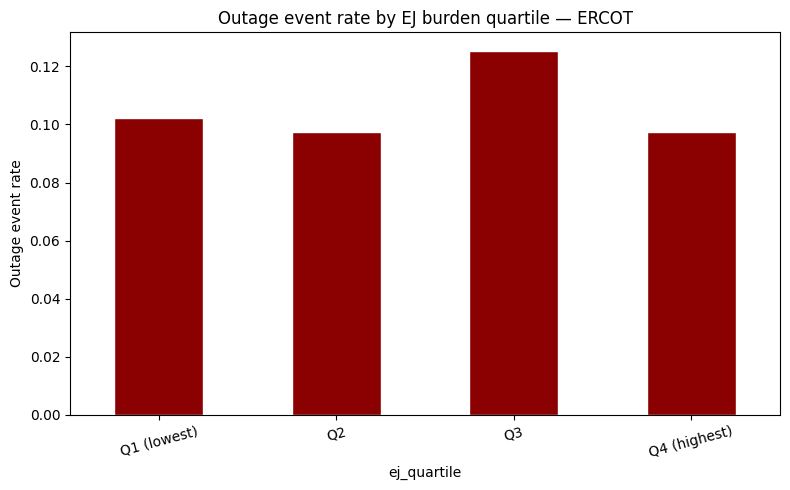

In [4]:
if ej_merged is not None and 'ej_index' in ej_merged.columns:
    ej_merged['ej_quartile'] = pd.qcut(ej_merged['ej_index'].rank(method='first'), 4,
                                        labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
    q_rates = ej_merged.groupby('ej_quartile')['outage_event_flag'].mean()
    print('Outage event rate by EJ burden quartile:')
    print(q_rates)

    fig, ax = plt.subplots(figsize=(8, 5))
    q_rates.plot(kind='bar', ax=ax, color='darkred', edgecolor='white')
    ax.set_title('Outage event rate by EJ burden quartile — ERCOT')
    ax.set_ylabel('Outage event rate')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig('../data/processed/ercot_ej_outage_rates.png', dpi=150)
    plt.show()


## 8.4 Regression: outage severity in high-EJ counties

In [5]:
if ej_merged is not None:
    model_cols = ['fips', 'date', 'total_customer_hours',
                  'heatwave_day', 'compound_triple', 'high_ej_burden']
    avail = [c for c in model_cols if c in ej_merged.columns]
    df_model = ej_merged[avail].dropna().set_index(['fips', 'date'])
    if 'high_ej_burden' in df_model.columns:
        result_ej = run_panel_ols(df_model, outcome='total_customer_hours',
                                  weather_vars=['heatwave_day', 'compound_triple'],
                                  controls=['high_ej_burden'], use_categories=False, log_outcome=True)
        print(result_ej.summary)


/burg-archive/home/mck2199/electric-grid-resilience/src/analysis/panel_regression.py:139: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

high_ej_burden

  return model.fit(cov_type="clustered", cluster_entity=True)


                              PanelOLS Estimation Summary                               
Dep. Variable:     log1p_total_customer_hours   R-squared:                        0.0296
Estimator:                           PanelOLS   R-squared (Between):              0.1450
No. Observations:                      284388   R-squared (Within):               0.0296
Date:                        Mon, May 11 2026   R-squared (Overall):              0.1245
Time:                                13:11:17   Log-likelihood                -5.628e+05
Cov. Estimator:                     Clustered                                           
                                                F-statistic:                      666.44
Entities:                                 133   P-value                           0.0000
Avg Obs:                               2138.3   Distribution:               F(13,284242)
Min Obs:                               409.00                                           
Max Obs:             

## 8.5 Interaction: compound weather x EJ burden

In [6]:
if ej_merged is not None and 'compound_triple' in ej_merged.columns and 'high_ej_burden' in ej_merged.columns:
    ej_merged['compound_x_ej'] = ej_merged['compound_triple'] * ej_merged['high_ej_burden']
    df_i = ej_merged[['fips', 'date', 'total_customer_hours',
                       'compound_triple', 'high_ej_burden', 'compound_x_ej']].dropna()
    result_int = run_panel_ols(df_i.set_index(['fips', 'date']),
                               outcome='total_customer_hours',
                               weather_vars=['compound_triple', 'high_ej_burden', 'compound_x_ej'], use_categories=False, log_outcome=True)
    print(result_int.summary)
    print('\nKey: compound_x_ej tests whether compound outage effect is LARGER in high-EJ counties.')


/burg-archive/home/mck2199/electric-grid-resilience/src/analysis/panel_regression.py:139: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

high_ej_burden

  return model.fit(cov_type="clustered", cluster_entity=True)


                              PanelOLS Estimation Summary                               
Dep. Variable:     log1p_total_customer_hours   R-squared:                        0.0263
Estimator:                           PanelOLS   R-squared (Between):              0.1446
No. Observations:                      284388   R-squared (Within):               0.0263
Date:                        Mon, May 11 2026   R-squared (Overall):              0.1238
Time:                                13:11:19   Log-likelihood                -5.633e+05
Cov. Estimator:                     Clustered                                           
                                                F-statistic:                      590.36
Entities:                                 133   P-value                           0.0000
Avg Obs:                               2138.3   Distribution:               F(13,284242)
Min Obs:                               409.00                                           
Max Obs:             

## 8.6 Forward projection: high-EJ + high-heat double-exposure counties

In [7]:
if ej_ercot is not None and PROCESSED['loca2_ercot'].exists():
    loca2 = pd.read_csv(PROCESSED['loca2_ercot'], dtype={'fips': str})
    mid = loca2[(loca2['scenario'] == 'ssp585') & (loca2['period_label'] == 'mid')]
    ej_loca2 = ej_ercot.reset_index().merge(mid[['fips', 'SU_delta']].dropna(), on='fips', how='inner')
    ej_loca2['both_high'] = (
        (ej_loca2.get('high_ej_burden', 0) == 1) &
        (ej_loca2['SU_delta'] >= ej_loca2['SU_delta'].quantile(0.75))
    ).astype(int)
    n_both = ej_loca2['both_high'].sum()
    print(f'Counties with HIGH EJ burden AND HIGH projected heat increase: {n_both}')
    print(ej_loca2[ej_loca2['both_high'] == 1][['fips', 'ej_index', 'SU_delta']].head(10))


Counties with HIGH EJ burden AND HIGH projected heat increase: 38
     fips  ej_index  SU_delta
3   48013  1.929109      40.0
5   48025  1.939008      40.0
7   48029  1.984024      40.0
11  48047  2.643958      40.0
15  48055  1.885062      40.0
17  48061  2.677122      40.0
27  48109  2.406594      40.0
28  48113  1.969963      40.0
29  48117  2.319434      40.0
31  48127  2.978921      40.0
